In [84]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

sys.version_info(major=3, minor=12, micro=1, releaselevel='final', serial=0)
matplotlib 3.8.3
numpy 1.26.4
pandas 2.2.0
sklearn 1.7.0
torch 2.7.1+cpu
cpu


# 数据预处理-加载

In [85]:
import unicodedata
import re
# 定义一个函数，将Unicode字符串转换为ASCII字符串
def unicode_to_ascii(s):
    # 使用unicodedata库将字符串标准化为NFD形式，然后过滤掉所有非ASCII字符
    # 这样可以去除西班牙语中的重音等特殊字符
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# 示例
# 加u代表对字符串进行unicode编码
en_sentence = u"May I borrow, this book?"
sp_sentence = u"¿Puedo tomar prestado este libro?"

print(unicode_to_ascii(en_sentence))
print(unicode_to_ascii(sp_sentence))

# 中文注释：该函数用于将Unicode字符串（如西班牙语中的带重音字符）转换为ASCII字符串，去除重音等特殊字符。


May I borrow, this book?
¿Puedo tomar prestado este libro?


In [86]:
def preprocess_sentence(w):
    # 将句子变为小写，去除首尾空格，并在单词和标点之间加空格
    w = w.lower().strip()  # 转小写并去除首尾空格
    # 在标点符号前后加空格，方便分词
    w = re.sub(r"([?.!,¿])", r" \1 ", w)
    # 将多个空格替换为单个空格
    w = re.sub(r'[" "]+', " ", w)
    # 去除除字母和标点外的其他字符
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)
    w = w.strip()
    return w

print(preprocess_sentence(en_sentence))
print(preprocess_sentence(sp_sentence))
print(preprocess_sentence(sp_sentence).encode('utf-8'))  #¿是占用两个字节的

may i borrow , this book ?
¿ puedo tomar prestado este libro ?
b'\xc2\xbf puedo tomar prestado este libro ?'


In [87]:
#划分训练集和测试集的一个方法
split_index1 = np.random.choice(a=["train", "test"], replace=True, p=[0.8, 0.2], size=100)
split_index1

array(['train', 'test', 'train', 'train', 'train', 'train', 'train',
       'test', 'train', 'train', 'train', 'test', 'test', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'test', 'test',
       'test', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'test', 'train', 'train', 'train', 'train', 'train',
       'train', 'test', 'train', 'test', 'test', 'train', 'test', 'train',
       'train', 'train', 'train', 'train', 'train', 'test', 'train',
       'train', 'train', 'train', 'test', 'train', 'test', 'train',
       'train', 'train', 'test', 'train', 'train', 'train', 'train',
       'train', 'train', 'test', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'test', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train'], dtype='<U5')

# Dataset

In [88]:
# 引入必要的库
import torch
from torch.utils.data import Dataset
import numpy as np
import os

class TranslationDataset(Dataset):
    """
    TranslationDataset类，继承自torch.utils.data.Dataset，用于加载和处理英西翻译数据集，支持缓存机制。
    """
    def __init__(self, path, num_examples=None, split=None):
        # 中文注释：初始化数据集，支持分割训练集和测试集，并缓存处理后的数据
        cache_file_en = f'{split}_en_sentences.npy' if split else 'all_en_sentences.npy'
        cache_file_sp = f'{split}_sp_sentences.npy' if split else 'all_sp_sentences.npy'
        # 中文注释：定义英语和西班牙语缓存文件名

        # 如果缓存文件存在，直接加载
        if os.path.exists(cache_file_en) and os.path.exists(cache_file_sp):
            print(f"Loading {split} data from cache files...")  # 英文提示：从缓存文件加载数据
            self.trg = np.load(cache_file_en, allow_pickle=True)  # 英语句子
            self.src = np.load(cache_file_sp, allow_pickle=True)  # 西班牙语句子
            # 中文注释：从缓存文件加载英语和西班牙语句子数组
        else:
            print(f"Reading data from {path} and creating {split} dataset...")  # 英文提示：从原始文件读取数据
            # 读取原始数据文件
            with open(path, encoding='utf-8') as f:
                lines = f.read().strip().split('\n')
            # 中文注释：读取原始数据文件的所有行

            # 创建空列表存储英语和西班牙语句子对
            en_sentences = []
            sp_sentences = []

            # 生成训练集和测试集的索引,如果num_examples为None，则使用所有行，否则使用num_examples行
            total_examples = len(lines) if num_examples is None else min(num_examples, len(lines)) 
            split_index = np.random.choice(a=["train", "test"], replace=True, p=[0.8, 0.2], size=total_examples)
            # 中文注释：生成训练集和测试集的分割索引

            # 遍历每一行，按tab分隔英语和西班牙语
            for i, line in enumerate(lines[:total_examples]):
                # 如果指定了split，则只保留对应的数据
                if split is not None and split_index[i] != split:
                    continue
                # 按tab分割每一行
                en, sp = line.split('\t')
                # 预处理句子
                en = preprocess_sentence(en)
                sp = preprocess_sentence(sp)
                # 添加到列表中
                en_sentences.append(en)
                sp_sentences.append(sp)

            # 转换为numpy数组
            self.trg = np.array(en_sentences)  # 英语
            self.src = np.array(sp_sentences)  # 西班牙语
            # 中文注释：将英语和西班牙语句子列表转换为numpy数组

            # 保存为numpy文件进行缓存
            np.save(cache_file_en, self.trg)
            np.save(cache_file_sp, self.src)
            # 中文注释：将英语和西班牙语句子数组保存为npy文件以便下次直接加载

    def __len__(self):
        # 中文注释：返回数据集的样本数量
        return len(self.trg)
    
    def __getitem__(self, idx):
        # 中文注释：根据索引返回一对（西班牙语，英语）句子
        return self.src[idx], self.trg[idx]  # 西班牙语，英语(目标语)

# 从spa.txt创建数据集
train_dataset = TranslationDataset('spa.txt', split='train')
test_dataset = TranslationDataset('spa.txt', split='test')
print(len(train_dataset))
print(len(test_dataset))
# 中文注释：分别输出训练集和测试集的样本数量

Loading train data from cache files...
Loading test data from cache files...
95332
23824


In [89]:
# 加载数据format(*)表示解包列表
print("source: {}\ntarget: {}".format(*train_dataset[-1]))

source: si quieres sonar como un hablante nativo , debes estar dispuesto a practicar diciendo la misma frase una y otra vez de la misma manera en que un m sico de banjo practica el mismo fraseo una y otra vez hasta que lo puedan tocar correctamente y en el tiempo esperado .
target: if you want to sound like a native speaker , you must be willing to practice saying the same sentence over and over in the same way that banjo players practice the same phrase over and over until they can play it correctly and at the desired tempo .


# Tokenizer

## 构建目标语言为英语，即将西班牙语翻译为英语的序列到序列模型

In [90]:
# 构建英语和西班牙语的词典
# English: Build vocabularies for English and Spanish
from collections import Counter

def build_vocab(sentences, min_freq=1, special_tokens=["<pad>", "<sos>", "<eos>", "<unk>"]):
    """
    构建词表，统计词频，保留出现频率大于等于min_freq的词，并添加特殊符号
    Build vocabulary, count word frequency, keep words with frequency >= min_freq, and add special tokens
    """
    word2idx = {
        "[PAD]": 0,     # 填充 token
        "[BOS]": 1,     # begin of sentence
        "[UNK]": 2,     # 未知 token
        "[EOS]": 3,     # end of sentence
    }
    # Counter() 统计单词出现的次数
    counter = Counter()
    for sent in sentences:
        counter.update(sent.split())
    # 只保留出现频率大于等于min_freq的词
    vocab = special_tokens + [word for word, freq in counter.items() if freq >= min_freq]
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}
    return vocab, word2idx, idx2word

# 分别为encoder和decoder构建词典（不共享embedding）
src_vocab, src_word2idx, src_idx2word = build_vocab(train_dataset.src, min_freq=1)
trg_vocab, trg_word2idx, trg_idx2word = build_vocab(train_dataset.trg, min_freq=1)

print("Source vocab size:", len(src_vocab))
print("Target vocab size:", len(trg_vocab))
# 中文注释：分别输出源语言和目标语言的词表大小


Source vocab size: 20951
Target vocab size: 11984


In [91]:
# 定义Tokenizer类，用于将文本和索引之间相互转换
# Define the Tokenizer class for converting between text and indices

class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        """
        初始化Tokenizer
        Initialize the Tokenizer
        """
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.unk_idx = unk_idx

    def encode(self,text_list,add_bos=True, add_eos=True, padding_first=False,return_mask=False):
        """
        将句子编码为索引列表，并进行padding和mask生成
        Encode a sentence into a list of indices, with optional padding and mask creation

        新增功能：根据text_list动态计算实际需要的最大长度，若句子长度超过最大长度，则截断
        New feature: Dynamically calculate the actual required max length based on text_list, truncate if sentence exceeds max length
        """
        max_length = min(self.max_length, add_eos + add_bos + max([len(text) for text in text_list]))  # 计算实际需要的最大长度
        indices_list = []  # 初始化索引列表
        for text in text_list:  # 遍历每个文本
            indices = [self.word2idx.get(word, self.unk_idx) for word in text[:max_length - add_bos - add_eos]]  # 将文本中的词转换为索引，如果词不在词表中则使用unk_idx
            if add_bos:  # 如果需要添加句子开始标记
                indices = [self.bos_idx] + indices  # 在序列开头添加BOS标记
            if add_eos:  # 如果需要添加句子结束标记
                indices = indices + [self.eos_idx]  # 在序列末尾添加EOS标记
            if padding_first:  # 如果padding需要加在前面
                indices = [self.pad_idx] * (max_length - len(indices)) + indices  # 在序列前面添加padding
            else:  # 如果padding需要加在后面
                indices = indices + [self.pad_idx] * (max_length - len(indices))  # 在序列后面添加padding
            indices_list.append(indices)  # 将处理后的索引添加到列表中
        input_ids = torch.tensor(indices_list)  # 将索引列表转换为tensor
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64)  # 创建mask，1表示padding位置，0表示实际token位置
        return input_ids if not return_mask else (input_ids, masks)  # 根据return_mask参数决定返回值

    # 中文注释：encode方法支持根据text_list动态计算最大长度，若句子长度超过最大长度则截断
    
    def decode(self, ids, remove_special_tokens=True, remove_eos=False, remove_pad=False):
        """
        将索引列表解码为句子
        Decode a list of indices back to a sentence
        """
        tokens = []
        for idx in ids:
            word = self.idx2word.get(idx, "[UNK]")
            if remove_special_tokens and word in ["[PAD]", "[BOS]", "[EOS]", "[UNK]"]:
                continue
            tokens.append(word)
        return ' '.join(tokens)

# 中文注释：Tokenizer类用于文本和索引的相互转换，encode方法支持padding_first参数，mask中1表示padding，0表示实际token


In [92]:
# 两个相对于1个tokenizer的好处是embedding的参数量减少
src_tokenizer = Tokenizer(word2idx=src_word2idx, idx2word=src_idx2word)  # 创建源语言(西班牙语)的tokenizer
trg_tokenizer = Tokenizer(word2idx=trg_word2idx, idx2word=trg_idx2word)  # 创建目标语言(英语)的tokenizer

batch_text = ["hello world".split(), "tokenize text datas with batch".split(), "this is a test".split()]
indices,mask = trg_tokenizer.encode(batch_text, padding_first=False, add_bos=True, add_eos=True,return_mask=True)

print("batch_text"+'-'*10)
for raw in batch_text:
    print(raw)
print("mask"+'-'*10)
for m in mask:
    print(m)
print("indices"+'-'*10)
for index in indices:
    print(index)

batch_text----------
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']
mask----------
tensor([0, 0, 0, 0, 1, 1, 1])
tensor([0, 0, 0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0, 0, 1])
indices----------
tensor([   1,   17, 3161,    3,    0,    0,    0])
tensor([   1,    2, 3673,    2,  530,    2,    3])
tensor([   1,  119,  228,  105, 1210,    3,    0])


# Dataloader

In [93]:
def collate_fn(batch):
    """
    数据批处理函数
    
    Args:
        batch: 批次数据
        src_tokenizer: 源语言tokenizer
        trg_tokenizer: 目标语言tokenizer
        device: 设备，如果指定则将tensor移至该设备
    Returns:
        包含编码后的tensor的字典
            "encoder_inputs": encoder input tensor
            "encoder_inputs_mask": encoder input mask tensor
            "decoder_inputs": decoder input tensor
            "decoder_labels": decoder label tensor
            "decoder_labels_mask": decoder label mask tensor
    """
    # 中文注释：collate_fn函数用于DataLoader批量处理数据，将文本批次转换为模型输入所需的tensor格式

    # 分别提取源语言和目标语言的句子
    src_texts = [item[0].split() for item in batch]
    trg_texts = [item[1].split() for item in batch]

    # 编码源语言句子，添加BOS和EOS
    encoder_inputs, encoder_inputs_mask = src_tokenizer.encode(
        src_texts, padding_first=True,add_bos=True, 
        add_eos=True, return_mask=True
    )
    # 编码目标语言句子，decoder_inputs加BOS，decoder_labels加EOS
    decoder_inputs, _ = trg_tokenizer.encode(
        trg_texts, add_bos=True, add_eos=False, return_mask=True
    )
    decoder_labels, decoder_labels_mask = trg_tokenizer.encode(
        trg_texts, add_bos=False, add_eos=True, return_mask=True
    )

    # 如果指定了设备，则将所有tensor移至该设备
    if device is not None:
        encoder_inputs = encoder_inputs.to(device)
        encoder_inputs_mask = encoder_inputs_mask.to(device)
        decoder_inputs = decoder_inputs.to(device)
        decoder_labels = decoder_labels.to(device)
        decoder_labels_mask = decoder_labels_mask.to(device)

    # 返回一个包含所有输入和mask的字典
    return {
        "encoder_inputs": encoder_inputs,  # 编码器输入
        "encoder_inputs_mask": encoder_inputs_mask,  # 编码器输入mask
        "decoder_inputs": decoder_inputs,  # 解码器输入
        "decoder_labels": decoder_labels,  # 解码器标签
        "decoder_labels_mask": decoder_labels_mask  # 解码器标签mask
    }
    # 中文注释：返回一个字典，包含编码器输入、mask，解码器输入、标签及其mask，便于模型训练时使用


In [94]:
from torch.utils.data import DataLoader
sample_dl = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

#两次执行这个代码效果不一样，因为每次执行都会shuffle
for batch in sample_dl:
    for key, value in batch.items():
        print(key)
        print(value)
    break

encoder_inputs
tensor([[   1,   40,  790,  602,   87, 3432,    7, 1156,   31, 2841,  262, 2130,
           74,  234, 1623,    5,    3],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    1, 2148,
         5509, 1139, 4184,    5,    3]])
encoder_inputs_mask
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])
decoder_inputs
tensor([[   1,   18,  114,  115,  385,  274,  588, 2113,  306,  660, 2242,  289,
          801,    5],
        [   1,   18, 1143,  205,  915, 2295,    5,    0,    0,    0,    0,    0,
            0,    0]])
decoder_labels
tensor([[  18,  114,  115,  385,  274,  588, 2113,  306,  660, 2242,  289,  801,
            5,    3],
        [  18, 1143,  205,  915, 2295,    5,    3,    0,    0,    0,    0,    0,
            0,    0]])
decoder_labels_mask
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]])


# 定义模型

In [95]:
import torch.nn as nn

class Encoder(nn.Module):
    """
    Encoder for Seq2Seq with Attention using GRU.
    编码器用于带注意力机制的Seq2Seq模型，采用GRU结构。
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1, dropout=0.1):
        """
        Initialize the encoder.

        Args:
        - vocab_size: 源语言词汇表大小
        初始化编码器

        参数:
        - vocab_size: 源语言词汇表大小
        - embedding_dim: 词嵌入维度
        - hidden_size: 隐藏状态维度
        - num_layers: GRU层数
        - dropout: Dropout比率
        """
        super().__init__()
        # Embedding layer for input tokens
        # 嵌入层，将输入token转换为词向量
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # GRU layer(s)
        # GRU层，可堆叠多层
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        # Dropout layer
        # Dropout层，防止过拟合
        self.dropout = nn.Dropout(dropout)
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers

    def forward(self, src, src_mask=None):
        """
        Forward pass of the encoder.

        前向传播

        参数:
        - src: 输入序列 (batch, seq_len)
        - src_mask: 输入mask（此处未用）

        返回:
        - outputs: 所有GRU隐藏状态 (batch, seq_len, hidden_size)
        - hidden: 最后时刻的隐藏状态 (num_layers, batch, hidden_size)
        """
        embedded = self.dropout(self.embedding(src))  # (batch, seq_len, embedding_dim)
        # 词嵌入后加dropout
        outputs, hidden = self.gru(embedded)  # outputs: (batch, seq_len, hidden_size)
        # 通过GRU获得所有时刻的输出和最后的隐藏状态
        return outputs, hidden
        # 返回所有GRU输出和最后隐藏状态


In [96]:
# 测试Encoder
import torch

# 创建测试参数
vocab_size = len(src_tokenizer.word2idx)
embedding_dim = 256
hidden_size = 512
num_layers = 2
dropout = 0.3
batch_size = 64
seq_len = 20

# 实例化Encoder
encoder = Encoder(vocab_size, embedding_dim, hidden_size, num_layers, dropout)

# 创建测试输入
src = torch.randint(0, vocab_size, (batch_size, seq_len))  # [batch_size, seq_len]

# 前向传播
encoder_outputs, hidden = encoder(src)

# 打印输出形状
print(f"源序列形状: {src.shape}")
print(f"编码器输出形状: {encoder_outputs.shape}")
print(f"隐藏状态形状: {hidden.shape}")

# 验证输出维度是否符合预期
assert encoder_outputs.shape == (batch_size, seq_len, hidden_size)
assert hidden.shape == (num_layers, batch_size, hidden_size)

print(hidden[-1,:,:].shape) #取最后一层的hidden

源序列形状: torch.Size([64, 20])
编码器输出形状: torch.Size([64, 20, 512])
隐藏状态形状: torch.Size([2, 64, 512])
torch.Size([64, 512])


In [97]:
# 模拟 logits 和 mask
logits = torch.tensor([[1.0, 2.0, 3.0, 4.0]])
mask = torch.tensor([[1, 1, 0, 0]])  # 只让前两个位置有效

# 把无效位置mask值设为 -inf
masked_logits = logits.masked_fill(mask == 1, float('-inf'))
masked_logits

tensor([[-inf, -inf, 3., 4.]])

# Bahdanau注意力

In [98]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim, key_size):
        super().__init__()
        # 定义线性层用于将key和query映射到同一维度
        # Define linear layers to map key and query to the same dimension
        self.W_key = nn.Linear(key_size, hidden_dim)
        self.W_query = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, query, keys, values, attn_mask=None):
        """
        query: 查询向量 (batch_size, hidden_dim)
        keys: 键向量 (batch_size, seq_len, key_size)
        values: 值向量 (batch_size, seq_len, value_size)
        attn_mask: 注意力掩码 (batch_size, seq_len), 1表示需要mask的位置
        Returns:
            attention_weights: 注意力权重 (batch_size, seq_len)
            context: 上下文向量 (batch_size, value_size)
        """
        # query: (batch_size, hidden_dim)
        # keys: (batch_size, seq_len, key_size)
        # values: (batch_size, seq_len, value_size)
        # attn_mask: (batch_size, seq_len)

        # 扩展query以便与keys相加
        # Expand query for addition with keys
        query_expanded = self.W_query(query).unsqueeze(1)  # (batch_size, 1, hidden_dim)
        
        keys_proj = self.W_key(keys)  # (batch_size, seq_len, hidden_dim)
        
        energy = torch.tanh(keys_proj + query_expanded)  # (batch_size, seq_len, hidden_dim)
        attention_scores = self.v(energy).squeeze(-1)  # (batch_size, seq_len)

        # 应用注意力掩码，将attn_mask为1的位置设为-inf
        # Apply attention mask, set masked positions to -inf
        if attn_mask is not None:
            attention_scores = attention_scores.masked_fill(attn_mask == 1, float('-inf'))

        # 计算注意力权重
        # Calculate attention weights
        attention_weights = F.softmax(attention_scores, dim=1)  # (batch_size, seq_len)

        # 计算上下文向量，torch.bmm 用于矩阵乘法
        # torch.mul#对每一个词的score和对应的value做乘法，然后在seq_len维度上求和，得到context_vector
        context = torch.mul(attention_weights.unsqueeze(-1), values).sum(dim=1)   # (batch_size, value_size)
        # context = context.squeeze(1)  #torch.bmm (batch_size, value_size)

        # 返回上下文向量,注意力权重
        # Return attention weights and context vector
        return context, attention_weights

# Bahdanau注意力机制类定义完毕
# Bahdanau attention mechanism class definition complete


## 测试注意力

Query shape: torch.Size([2, 8])
Keys shape: torch.Size([2, 4, 8])
Values shape: torch.Size([2, 4, 8])
Context vector shape: torch.Size([2, 8])
Attention weights shape: torch.Size([2, 4])

Attention weights:
tensor([[0.0000, 0.3437, 0.2703, 0.3860],
        [0.2310, 0.2162, 0.2863, 0.2666]], grad_fn=<SoftmaxBackward0>)


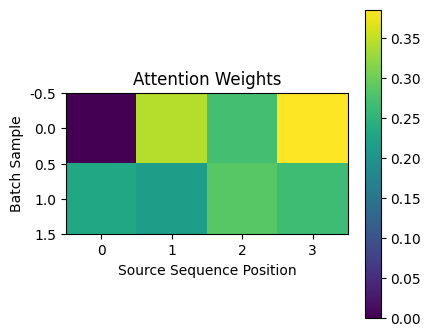

In [99]:
# 测试BahdanauAttention
def test_bahdanau_attention():
    # 设置参数
    batch_size = 2
    hidden_size = 8
    src_len = 4
    
    # 创建输入数据
    query = torch.randn(batch_size, hidden_size)  # Decoder的隐藏状态
    keys = torch.randn(batch_size, src_len, hidden_size)  # Encoder输出
    values = torch.randn(batch_size, src_len, hidden_size)  # 通常与keys相同
    
    # 创建注意力掩码，模拟序列填充的情况
    attn_mask = torch.zeros(batch_size, src_len)
    attn_mask[0, 0] = 1  # 假设第一个样本的最后一个token是padding
    # attn_mask[1, 2:] = 1  # 假设第二个样本的最后两个tokens是padding
    
    # 初始化Bahdanau注意力机制
    attention = BahdanauAttention(hidden_size, hidden_size)
    
    # 前向传播
    context, attn_weights = attention(query, keys, values, attn_mask)
    
    # 打印结果
    print(f"Query shape: {query.shape}")
    print(f"Keys shape: {keys.shape}")
    print(f"Values shape: {values.shape}")
    print(f"Context vector shape: {context.shape}")
    print(f"Attention weights shape: {attn_weights.shape}")
    
    # 验证注意力权重是否在掩码位置接近于0
    print("\nAttention weights:")
    print(attn_weights)
    
    # 可视化注意力权重
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(attn_weights.detach().numpy(), cmap='viridis')
    plt.colorbar()
    plt.title('Attention Weights')
    plt.xlabel('Source Sequence Position')
    plt.ylabel('Batch Sample')
    
    return context, attn_weights

# 运行测试
context, attn_weights = test_bahdanau_attention()


# 解码器Decoder

In [ ]:
# 带有注意力机制的GRU解码器类，用于Seq2Seq模型
# Decoder class with attention mechanism for Seq2Seq model (using GRU)
class Decoder1(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        """
        vocab_size: 目标词表大小
        embedding_dim: 词嵌入维度
        hidden_dim: 隐藏层维度
        num_layers: GRU层数
        dropout: dropout比例
        """
        super().__init__()
        self.vocab_size = vocab_size  # 输出词表大小 (Output vocabulary size)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)  # 词嵌入层 (Embedding layer)
        self.gru = nn.GRU(embedding_dim + hidden_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)  # GRU层 (GRU layer)，bidirectional 为 False，即单向 GRU
        self.fc_out = nn.Linear(hidden_dim, vocab_size)  # 输出层 (Output layer),hidden_dim * 2 因为 bidirectional是双向
        self.dropout = nn.Dropout(dropout)  # dropout层 (Dropout layer)

        # 注意力层 (Attention layers)
        self.attention = BahdanauAttention(hidden_dim,key_size = hidden_size)  # 用于计算注意力能量 (For attention energy)
        

    def forward(self, decoder_input, hidden, encoder_outputs, attn_mask=None):
        """
        decoder_input: 当前输入token (batch, 1) (Current input token)
        hidden: 上一时刻的隐藏状态 (num_layers, batch, hidden_dim) (Previous hidden state)
        encoder_outputs: 编码器输出 (batch, src_len, hidden_dim) (Encoder outputs)
        attn_mask: (batch, src_len) 1为有效，0为pad (Mask for padding)
        返回:
            output: 当前时刻的输出 (batch, vocab_size) (Current output)
            hidden: 当前时刻的隐藏状态 (Current hidden state)
            attention_score: 注意力权重 (batch, src_len) (Attention weights)
        """

        #断言，确保输入的形状是正确的
        # decoder_input.shape = [batch size, 1]
        assert len(decoder_input.shape) == 2 and decoder_input.shape[-1] == 1, f"decoder_input.shape = {decoder_input.shape} is not valid"
        # hidden.shape = [batch size, hidden_dim]，decoder_hidden,而第一次使用的是encoder的hidden
        assert len(hidden.shape) == 2, f"hidden.shape = {hidden.shape} is not valid"
        # encoder_outputs.shape = [batch size, sequence length, hidden_dim]
        assert len(encoder_outputs.shape) == 3, f"encoder_outputs.shape = {encoder_outputs.shape} is not valid"
        # context_vector.shape = [batch_size, hidden_dim]

        # 注意力机制
        context_vector, attention_score = self.attention(
            query=hidden, keys=encoder_outputs, values=encoder_outputs, attn_mask=attn_mask)
        # decoder_input.shape = [batch size, 1]-->embeds.shape = [batch size, 1, embedding_dim]
        embeds = self.embedding(decoder_input)

        # context_vector.shape = [batch size, hidden_dim] -->unsqueeze(-2)增加维度 [batch size, 1, hidden_dim]
        embeds = torch.cat([context_vector.unsqueeze(-2), embeds], dim=-1)
        # 新的embeds.shape = [batch size, 1, embedding_dim + hidden_dim]
        seq_output, hidden = self.gru(embeds) #这里需要把前面的decode hidden再次输入，需要改进
        # seq_output.shape = [batch size, 1, hidden_dim]
        logits = self.fc_out(self.dropout(seq_output)) #
        # logits.shape = [batch size, 1, vocab size]，attention_score = [batch size, sequence length, 1]
        return logits, hidden, attention_score

        embeds = self.embedding(decoder_input)  # (batch, 1, embedding_dim)

        # 拼接嵌入和上下文向量作为GRU输入 (Concatenate embedding and context vector for GRU input)
        # context_vector 需要扩展一个时间步维度 (context_vector needs to be unsqueezed to [batch, 1, hidden_dim])
        gru_input = torch.cat([embeds, context_vector.unsqueeze(1)], dim=2)  # (batch, 1, embedding_dim + hidden_dim)

        # GRU前向传播 (GRU forward)
        output, hidden = self.gru(gru_input, hidden)  # output: (batch, 1, hidden_dim)

        # 拼接GRU输出和上下文向量 (Concatenate GRU output and context vector)
        output = output.squeeze(1)  # (batch, hidden_dim)
        output_context = torch.cat([output, context_vector], dim=1)  # (batch, hidden_dim*2)

        # 预测下一个token (Predict next token)
        prediction = self.fc_out(output_context)  # (batch, vocab_size)

        # 返回预测结果、隐藏状态和注意力分数
        # Return prediction, hidden, attention_score
        return prediction, hidden, attention_score  # 返回预测结果、隐藏状态和注意力分数

        

# 这是一个带有注意力机制的GRU解码器
# This is a GRU decoder with attention mechanism

In [ ]:
# 前向计算验证Decoder是否ok

batch_size = 2
seq_len = 5
hidden_layer= 1
hidden_dim = 32
vocab_size = 1000
embedding_dim = 64

# 创建模拟数据
decoder_input = torch.randint(0, vocab_size, (batch_size, 1))  # [batch_size, 1]
decoder_hidden = torch.randn(hidden_layer,batch_size, hidden_dim)  # [batch_size, hidden_dim]
encoder_outputs = torch.randn(batch_size, seq_len, hidden_dim)  # [batch_size, seq_len, hidden_dim]
attn_mask = torch.ones(batch_size, seq_len)  # [batch_size, seq_len]

# 创建Decoder模型
decoder = Decoder1(vocab_size, embedding_dim, hidden_dim=hidden_dim,num_layers=1, dropout=0.5)

# 前向计算
logits, hidden, attention_score = decoder(decoder_input, decoder_hidden, encoder_outputs, attn_mask)

# 打印输出形状
print(f"decoder_input.shape: {decoder_input.shape}")
print(f"decoder_hidden.shape: {decoder_hidden.shape}")
print(f"encoder_outputs.shape: {encoder_outputs.shape}")
print(f"logits.shape: {logits.shape}")
print(f"hidden.shape: {hidden.shape}")
print(f"attention_score.shape: {attention_score.shape}")

In [103]:
class Decoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=1024,
        num_layers=1,
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim + hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size) #最后分类,词典大小是多少，就输出多少个分类
        self.dropout = nn.Dropout(0.5) #0.6可以调整的超参数
        self.attention = BahdanauAttention(hidden_dim,hidden_dim) #注意力得到的context_vector

    def forward(self, decoder_input, hidden, encoder_outputs, attn_mask=None):
        """
        参数:
            decoder_input: 解码器的输入，形状为 [batch_size, 1]
            hidden: 解码器的隐藏状态，形状为 [batch_size, hidden_dim],第一次使用的是encoder的hidden
            encoder_outputs: 编码器的输出，形状为 [batch_size, sequence_length, hidden_dim]
            attn_mask: 注意力掩码，形状为 [batch_size, sequence_length],是encoder_inputs_mask
        
        返回:
            logits: 解码器的输出，形状为 [batch_size, 1, vocab_size]
            hidden: 解码器的隐藏状态，形状为 [batch_size, hidden_dim]
            attention_score: 注意力权重，形状为 [batch_size, sequence_length, 1]
        """
        #断言，确保输入的形状是正确的
        # decoder_input.shape = [batch size, 1]
        assert len(decoder_input.shape) == 2 and decoder_input.shape[-1] == 1, f"decoder_input.shape = {decoder_input.shape} is not valid"
        # hidden.shape = [batch size, hidden_dim]，decoder_hidden,而第一次使用的是encoder的hidden
        assert len(hidden.shape) == 2, f"hidden.shape = {hidden.shape} is not valid"
        # encoder_outputs.shape = [batch size, sequence length, hidden_dim]
        assert len(encoder_outputs.shape) == 3, f"encoder_outputs.shape = {encoder_outputs.shape} is not valid"
        # context_vector.shape = [batch_size, hidden_dim]
        
        # 注意力机制
        context_vector, attention_score = self.attention(
            query=hidden, keys=encoder_outputs, values=encoder_outputs, attn_mask=attn_mask)
        # decoder_input.shape = [batch size, 1]-->embeds.shape = [batch size, 1, embedding_dim]
        embeds = self.embedding(decoder_input)

        # context_vector.shape = [batch size, hidden_dim] -->unsqueeze(-2)增加维度 [batch size, 1, hidden_dim]
        embeds = torch.cat([context_vector.unsqueeze(-2), embeds], dim=-1)
        # 新的embeds.shape = [batch size, 1, embedding_dim + hidden_dim]
        seq_output, hidden = self.gru(embeds) #这里需要把前面的decode hidden再次输入，需要改进
        # seq_output.shape = [batch size, 1, hidden_dim]
        logits = self.fc(self.dropout(seq_output)) #
        # logits.shape = [batch size, 1, vocab size]，attention_score = [batch size, sequence length, 1]
        return logits, hidden, attention_score

In [104]:
# 前向计算验证Decoder是否ok
batch_size = 2
seq_len = 5
hidden_dim = 32
vocab_size = 1000
embedding_dim = 64

# 创建模拟数据
decoder_input = torch.randint(0, vocab_size, (batch_size, 1))  # [batch_size, 1]
decoder_hidden = torch.randn(batch_size, hidden_dim)  # [batch_size, hidden_dim]
encoder_outputs = torch.randn(batch_size, seq_len, hidden_dim)  # [batch_size, seq_len, hidden_dim]
attn_mask = torch.ones(batch_size, seq_len)  # [batch_size, seq_len]

# 创建Decoder模型
decoder = Decoder(vocab_size, embedding_dim, hidden_dim)

# 前向计算
logits, hidden, attention_score = decoder(decoder_input, decoder_hidden, encoder_outputs, attn_mask)

# 打印输出形状
print(f"decoder_input.shape: {decoder_input.shape}")
print(f"decoder_hidden.shape: {decoder_hidden.shape}")
print(f"encoder_outputs.shape: {encoder_outputs.shape}")
print(f"logits.shape: {logits.shape}")
print(f"hidden.shape: {hidden.shape}")
print(f"attention_score.shape: {attention_score.shape}")


decoder_input.shape: torch.Size([2, 1])
decoder_hidden.shape: torch.Size([2, 32])
encoder_outputs.shape: torch.Size([2, 5, 32])
logits.shape: torch.Size([2, 1, 1000])
hidden.shape: torch.Size([1, 2, 32])
attention_score.shape: torch.Size([2, 5])


# seq2seq模型

In [117]:
# Seq2Seq模型定义，支持for循环逐步解码，并新增translate方法
# Seq2Seq model definition, using a for loop for step-by-step decoding, and adding a translate method

import torch
import torch.nn as nn

class Seq2Seq(nn.Module):
    def __init__(self, input_vocab_size, output_vocab_size, embedding_dim, hidden_dim, num_layers=1, bidirectional=False, dropout=0.1):
        """
        input_vocab_size: 输入词表大小 (Input vocabulary size)
        output_vocab_size: 输出词表大小 (Output vocabulary size)
        embedding_dim: 词嵌入维度 (Embedding dimension)
        hidden_dim: 隐藏层维度 (Hidden dimension)
        num_layers: RNN层数 (Number of RNN layers)
        bidirectional: 是否双向 (Whether encoder is bidirectional)
        dropout: dropout比例 (Dropout rate)
        """
        super().__init__()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        # 编码器 (Encoder)
        self.encoder = Encoder(input_vocab_size, embedding_dim, hidden_dim, num_layers, bidirectional)
        # 解码器 (Decoder)
        self.decoder = Decoder(output_vocab_size, embedding_dim, hidden_dim * (2 if bidirectional else 1), num_layers)
        self.output_dim = output_vocab_size  # 输出词表大小 (Output vocabulary size)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        """
        src: 源序列 (batch, src_len)
        trg: 目标序列 (batch, trg_len)
        teacher_forcing_ratio: 使用教师强制的概率 (Teacher forcing ratio)
        Returns:
            outputs: 解码器所有时刻的输出 (batch, trg_len, vocab_size)
        """
        # 编码器前向传播 (Encoder forward)
        encoder_outputs, hidden = self.encoder(src)
        # encoder_outputs: (batch, src_len, hidden_size)
        # hidden: (num_layers, batch, hidden_size)

        batch_size = trg.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.output_dim

        # 用于存储解码器的输出 (To store decoder outputs)
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)

        # 第一个输入给解码器的是 <sos> token (First input to decoder is <sos> token)
        input = trg[:, 0].unsqueeze(1)  # (batch, 1)

        # 解码器的初始隐藏状态通常用编码器的最后隐藏状态 (Initial decoder hidden state from encoder)
        decoder_hidden = hidden

        for t in range(1, trg_len):
            # 解码器前向传播 (Decoder forward)
            output, decoder_hidden, _ = self.decoder(input, decoder_hidden, encoder_outputs)
            # output: (batch, vocab_size)
            outputs[:, t] = output.squeeze(1)

            # 决定是否使用教师强制 (Decide whether to use teacher forcing)
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            # 选择下一个输入 (Choose next input)
            top1 = output.argmax(2)  # (batch, 1)
            input = trg[:, t].unsqueeze(1) if teacher_force else top1

        return outputs
        # 返回所有时刻的输出 (Return outputs for all time steps)

    def translate(self, src, src_mask=None, max_len=50, sos_idx=1, eos_idx=3):
        """
        对单个样本或batch进行翻译推理 (Translate a single sample or batch)
        src: 源序列 (batch, src_len)
        src_mask: 源序列掩码 (batch, src_len)，可选 (Optional source mask)
        max_len: 最大解码长度 (Maximum decoding length)
        sos_idx: <sos> token的索引 (Index of <sos> token)
        eos_idx: <eos> token的索引 (Index of <eos> token)
        Returns:
            translations: (batch, max_len) 解码出的token索引 (Decoded token indices)
        """
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden = self.encoder(src)
            batch_size = src.shape[0]
            input = torch.full((batch_size, 1), sos_idx, dtype=torch.long, device=src.device)  # (batch, 1)
            decoder_hidden = hidden
            translations = torch.zeros(batch_size, max_len, dtype=torch.long, device=src.device)
            translations[:, 0] = sos_idx

            for t in range(1, max_len):
                output, decoder_hidden, _ = self.decoder(input, decoder_hidden, encoder_outputs, attn_mask=src_mask)
                top1 = output.argmax(2)  # (batch, 1)
                translations[:, t] = top1.squeeze(1)
                input = top1
                # 如果所有样本都已生成eos，则提前结束 (If all samples have generated <eos>, stop early)
                if (translations[:, t] == eos_idx).all():
                    break
        return translations
        # 返回翻译结果 (Return translation results)

# 以上为Seq2Seq模型定义，支持for循环逐步解码，并新增translate方法
# The above is the Seq2Seq model definition, using a for loop for step-by-step decoding, and adding a translate method


# 训练

In [106]:
class Sequence2Sequence(nn.Module):
    def __init__(
        self,
        src_vocab_size, #输入词典大小
        trg_vocab_size, #输出词典大小
        encoder_embedding_dim=256,
        encoder_hidden_dim=1024,
        encoder_num_layers=1,
        decoder_embedding_dim=256,
        decoder_hidden_dim=1024,
        decoder_num_layers=1,
        bos_idx=1,
        eos_idx=3,
        max_length=512,
        ):
        super(Sequence2Sequence, self).__init__()
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.max_length = max_length
        self.encoder = Encoder(
            src_vocab_size,
            embedding_dim=encoder_embedding_dim,
            hidden_size=encoder_hidden_dim,
            num_layers=encoder_num_layers,
            dropout=0.5
            )
        self.decoder = Decoder(
            trg_vocab_size,
            embedding_dim=decoder_embedding_dim,
            hidden_dim=decoder_hidden_dim,
            num_layers=decoder_num_layers,
            )

    def forward(self, *, encoder_inputs, decoder_inputs, attn_mask=None):
        # encoding
        encoder_outputs, hidden = self.encoder(encoder_inputs)
        # decoding with teacher forcing
        bs, seq_len = decoder_inputs.shape
        logits_list = []
        scores_list = []
        for i in range(seq_len):#串行训练
            # 每次迭代生成一个时间步的预测，存储在 logits_list 中，并且记录注意力分数（如果有的话）在 scores_list 中，最后将预测的logits和注意力分数拼接并返回。
            logits, hidden, score = self.decoder(
                decoder_inputs[:, i:i+1],
                hidden[-1], #取最后一层的hidden
                encoder_outputs,
                attn_mask=attn_mask
                )
            logits_list.append(logits) #记录预测的logits，用于计算损失
            scores_list.append(score) #记录注意力分数,用于画图

        return torch.cat(logits_list, dim=-2), torch.cat(scores_list, dim=-1)

    @torch.no_grad() #不计算梯度
    def infer(self, encoder_input, attn_mask=None):
        #infer用于预测
        # encoder_input.shape = [1, sequence length]
        # encoding
        encoder_outputs, hidden = self.encoder(encoder_input)

        # decoding，[[1]]
        decoder_input = torch.Tensor([self.bos_idx]).reshape(1, 1).to(dtype=torch.int64) #shape为[1,1]，内容为开始标记
        decoder_pred = None
        pred_list = [] #预测序列
        score_list = []
        # 从开始标记 bos_idx 开始，迭代地生成序列，直到生成结束标记 eos_idx 或达到最大长度 max_length。
        for _ in range(self.max_length):
            logits, hidden, score = self.decoder(
                decoder_input,
                hidden[-1],
                encoder_outputs,
                attn_mask=attn_mask
                )
            # using greedy search
            decoder_pred = logits.argmax(dim=-1)
            decoder_input = decoder_pred
            pred_list.append(decoder_pred.reshape(-1).item())
            score_list.append(score) #记录注意力分数,用于画图

            # stop at eos token
            if decoder_pred == self.eos_idx:
                break

        # return
        return pred_list, torch.cat(score_list, dim=-1)



## 损失函数

In [107]:
def cross_entropy_with_padding(logits, labels, padding_mask=None):
    # logits.shape = [batch size, sequence length, num of classes]
    # labels.shape = [batch size, sequence length]
    # padding_mask.shape = [batch size, sequence length]
    bs, seq_len, nc = logits.shape
    loss = F.cross_entropy(logits.reshape(bs * seq_len, nc), labels.reshape(-1), reduce=False) #reduce=False表示不对batch求平均
    if padding_mask is None:#如果没有padding_mask，就直接求平均
        loss = loss.mean()
    else:
        # 如果提供了 padding_mask，则将填充部分的损失去除后计算有效损失的均值。首先，通过将 padding_mask reshape 成一维张量，并取 1 减去得到填充掩码。这样填充部分的掩码值变为 1，非填充部分变为 0。将损失张量与填充掩码相乘，这样填充部分的损失就会变为 0。然后，计算非填充部分的损失和（sum）以及非填充部分的掩码数量（sum）作为有效损失的均值计算。(因为上面我们设计的mask的token是0，所以这里是1-padding_mask)
        padding_mask = 1 - padding_mask.reshape(-1) #将padding_mask reshape成一维张量，mask部分为0，非mask部分为1
        loss = torch.mul(loss, padding_mask).sum() / padding_mask.sum()

    return loss

## Callback

In [108]:
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            )

    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,

        )

    def __call__(self, step, **kwargs):
        # add loss
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


In [109]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    for batch in dataloader:
        encoder_inputs = batch["encoder_inputs"]
        encoder_inputs_mask = batch["encoder_inputs_mask"]
        decoder_inputs = batch["decoder_inputs"]
        decoder_labels = batch["decoder_labels"]
        decoder_labels_mask = batch["decoder_labels_mask"]

        # 前向计算
        logits, _ = model(
            encoder_inputs=encoder_inputs,
            decoder_inputs=decoder_inputs,
            attn_mask=encoder_inputs_mask
            ) #model就是seq2seq模型
        loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)         # 验证集损失
        loss_list.append(loss.cpu().item())

    return np.mean(loss_list)


In [110]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = - np.inf

        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



In [111]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = - np.inf
        self.counter = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter
            self.counter = 0
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience


In [112]:
# 训练
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }

    global_step = 1
    model.train() # 切换到训练模式
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for batch in train_loader:
                encoder_inputs = batch["encoder_inputs"]
                encoder_inputs_mask = batch["encoder_inputs_mask"]
                decoder_inputs = batch["decoder_inputs"]
                decoder_labels = batch["decoder_labels"]
                decoder_labels_mask = batch["decoder_labels_mask"]

                # 梯度清空
                optimizer.zero_grad()

                # 前向计算
                logits, _ = model(
                    encoder_inputs=encoder_inputs,
                    decoder_inputs=decoder_inputs,
                    attn_mask=encoder_inputs_mask
                    )
                loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)

                # 梯度回传
                loss.backward()

                # 调整优化器，包括学习率的变动等
                optimizer.step()

                loss = loss.cpu().item()
                # record
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })

                # evaluating
                if global_step % eval_step == 0:
                    model.eval() # 切换到验证模式
                    val_loss = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train() # 切换到训练模式

                    # 1. 使用 tensorboard 可视化
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            lr=optimizer.param_groups[0]["lr"],
                            )

                    # 2. 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # udate step
                global_step += 1
                pbar.update(1)
            pbar.set_postfix({"epoch": epoch_id, "loss": loss, "val_loss": val_loss})

    return record_dict


In [118]:
epoch = 20
batch_size = 64
input_vocab_size=len(train_dataset)
output_vocab_size=len(test_dataset)

model1 = Seq2Seq(
    input_vocab_size,
    output_vocab_size,
    embedding_dim=256,
    hidden_dim=512,  # 添加此行以修复错误
    num_layers=1,
    dropout=0.5
)

model = Sequence2Sequence(src_vocab_size=input_vocab_size, trg_vocab_size=output_vocab_size)

train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# 1. 定义损失函数 采用交叉熵损失
loss_fct = cross_entropy_with_padding
# 2. 定义优化器 采用 adam
# Optimizers specified in the torch.optim package
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 1. tensorboard 可视化
if not os.path.exists("runs"):
    os.mkdir("runs")
exp_name = "translate-seq2seq"
tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")
# tensorboard_callback.draw_model(model, [1, MAX_LENGTH])
# 2. save best
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback(
    f"checkpoints/{exp_name}", save_step=200, save_best_only=True)
# 3. early stop
early_stop_callback = EarlyStopCallback(patience=5)

model = model.to(device)


In [ ]:

record = training(
    model,
    train_dl,
    test_dl,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=tensorboard_callback,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=200
    )